In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Markov Decision Process (MDP) Framework

In [2]:
class GridWorld:
    """
    A simple 4x4 GridWorld MDP.
    State: (row, col). Goal: reach (3,3). Pit: (2,2).
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.goal = (size-1, size-1)
        self.pit = (size//2, size//2)
        self.action_effects = [(-1,0),(1,0),(0,-1),(0,1)]  # U D L R

    def state_id(self, s): return s[0]*self.size + s[1]
    def state_xy(self, sid): return (sid // self.size, sid % self.size)

    def reset(self):
        self.pos = (0, 0)
        return self.state_id(self.pos)

    def step(self, action):
        dr, dc = self.action_effects[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)
        done = False
        if self.pos == self.goal:
            reward, done = +10.0, True
        elif self.pos == self.pit:
            reward, done = -10.0, True
        else:
            reward = -0.1       # small step penalty encourages efficiency
        return self.state_id(self.pos), reward, done

env = GridWorld()
print(f"GridWorld: {env.n_states} states, {env.n_actions} actions")
print(f"Goal state id: {env.state_id(env.goal)}, Pit state id: {env.state_id(env.pit)}")

GridWorld: 16 states, 4 actions
Goal state id: 15, Pit state id: 10


---
## Reinforce: Monte Carlo Policy Gradient

From the **Policy Gradient Theorem**,

$$\nabla_\theta J(\theta) = \mathbb{E}_{s \sim \mu^{\pi_\theta},\, a \sim \pi_\theta} \bigl[\nabla_\theta \ln \pi(s,a;\theta) \cdot Q^{\pi_\theta}(s,a)\bigr]$$

REINFORCE approximates $Q$ with the Monte Carlo return $G_t = \sum_{s=t+1}^M \gamma^{s-t-1} r_s$

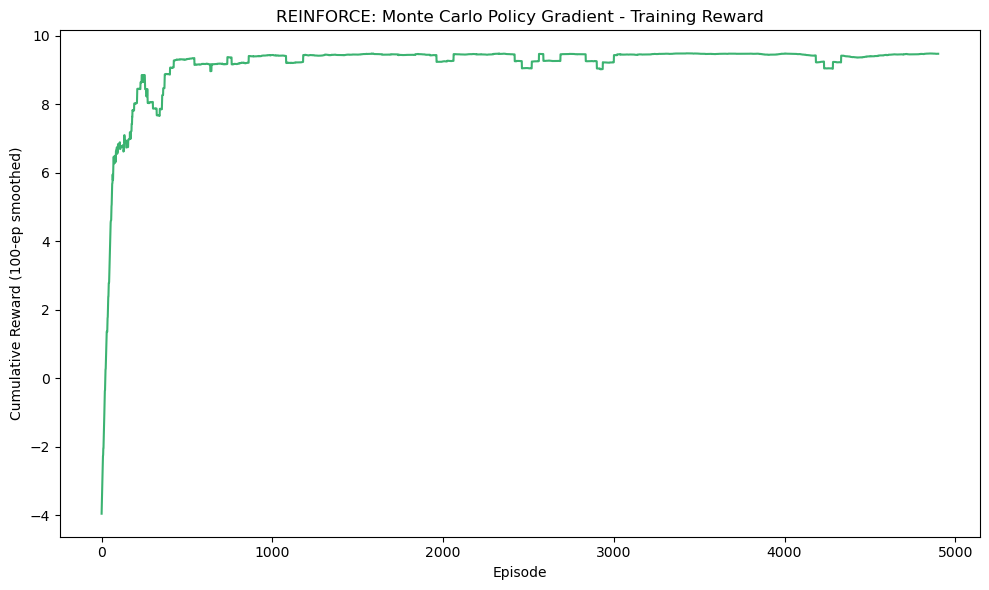

Final smoothed reward (REINFORCE): 9.474


In [3]:
class SoftmaxPolicy:
    """
    Tabular softmax policy: pi(a|s; theta) = exp(theta[s,a]) / sum_a' exp(theta[s,a'])
    This parametrizes pi differentiably, as required by the policy gradient theorem.
    """
    def __init__(self, n_states, n_actions, temperature=1.0):
        self.theta = np.zeros((n_states, n_actions))
        self.tau = temperature

    def probs(self, s):
        logits = self.theta[s] / self.tau
        logits -= logits.max()   # numerical stability
        exp_l = np.exp(logits)
        return exp_l / exp_l.sum()

    def select_action(self, s):
        return np.random.choice(len(self.theta[s]), p=self.probs(s))

    def log_grad(self, s, a):
        """Gradient of log pi(a|s) w.r.t. theta[s,:] (one-hot minus probs)"""
        p = self.probs(s)
        grad = -p.copy()
        grad[a] += 1.0
        return grad


def reinforce(env, num_episodes=5000, gamma=0.99, lr=0.01):
    """
    REINFORCE — Monte Carlo Policy Gradient.
    
    Updates theta using the full-trajectory return G_t:
      theta <- theta + beta * gamma^t * G_t * grad_theta log pi(s_t, a_t; theta)
    """
    policy = SoftmaxPolicy(env.n_states, env.n_actions)
    cum_rewards = []

    for ep in range(num_episodes):
        # 1. Collect full trajectory
        trajectory = []  # (s, a, r)
        s = env.reset()
        done = False
        while not done:
            a = policy.select_action(s)
            s_next, r, done = env.step(a)
            trajectory.append((s, a, r))
            s = s_next

        cum_rewards.append(sum(x[2] for x in trajectory))

        # 2. Compute returns G_t (discounted sum of future rewards)
        M = len(trajectory)
        G = np.zeros(M)
        G[-1] = trajectory[-1][2]
        for t in range(M-2, -1, -1):
            G[t] = trajectory[t][2] + gamma * G[t+1]

        # 3. Policy gradient update (Eq. 2.29)
        for t, (s, a, _) in enumerate(trajectory):
            policy.theta[s] += lr * (gamma**t) * G[t] * policy.log_grad(s, a)

    return policy, cum_rewards


policy_rf, rewards_rf = reinforce(env, num_episodes=5000)

window = 100
smooth_rf = np.convolve(rewards_rf, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(smooth_rf, color='mediumseagreen')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward (100-ep smoothed)')
plt.title('REINFORCE: Monte Carlo Policy Gradient - Training Reward')
plt.tight_layout()
plt.show()
print(f"Final smoothed reward (REINFORCE): {smooth_rf[-1]:.3f}")